
# Project: Customer Churn Prediction with XGBoost + SHAP

Predict which telecom customers will leave, explain why with SHAP, choose the best threshold using business cost, and turn the reasons into retention actions.

## What this notebook does
- Loads the public IBM Telco churn dataset (falls back to made-up Telco-style data if the download fails)
- Cleans the data and builds a Logistic Regression baseline
- Trains XGBoost with class imbalance handling
- Checks AUC, precision, recall and the confusion matrix
- Picks the threshold with the best expected profit using cross-validation on the training data, then checks it on the test data
- Explains the model with SHAP (global and per customer)
- Maps churn reasons to retention actions and exports a call list

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost shap

## Step 2: Load the data

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(10)
sns.set_style("whitegrid")

def make_telco(n=6000):
    tenure = np.random.randint(0, 73, n)
    contract = np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.22, 0.23])
    internet = np.random.choice(["DSL", "Fiber optic", "No"], n, p=[0.35, 0.45, 0.2])
    monthly = np.round(np.where(internet == "Fiber optic", np.random.normal(90, 15, n), np.where(internet == "DSL", np.random.normal(58, 12, n), np.random.normal(22, 5, n))), 2)
    df = pd.DataFrame({
        "customerID": ["C" + str(i) for i in range(n)],
        "gender": np.random.choice(["Male", "Female"], n),
        "SeniorCitizen": np.random.choice([0, 1], n, p=[0.84, 0.16]),
        "Partner": np.random.choice(["Yes", "No"], n),
        "Dependents": np.random.choice(["Yes", "No"], n, p=[0.3, 0.7]),
        "tenure": tenure,
        "PhoneService": np.random.choice(["Yes", "No"], n, p=[0.9, 0.1]),
        "InternetService": internet,
        "OnlineSecurity": np.where(internet == "No", "No internet service", np.random.choice(["Yes", "No"], n)),
        "TechSupport": np.where(internet == "No", "No internet service", np.random.choice(["Yes", "No"], n)),
        "StreamingTV": np.where(internet == "No", "No internet service", np.random.choice(["Yes", "No"], n)),
        "Contract": contract,
        "PaperlessBilling": np.random.choice(["Yes", "No"], n, p=[0.6, 0.4]),
        "PaymentMethod": np.random.choice(["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"], n),
        "MonthlyCharges": monthly,
    })
    df["TotalCharges"] = (df["tenure"] * df["MonthlyCharges"]).round(2).astype(str)
    score = (-0.6 + (df["Contract"] == "Month-to-month") * 1.3 - (df["Contract"] == "Two year") * 1.2 - df["tenure"] * 0.03
             + (df["InternetService"] == "Fiber optic") * 0.7 + (df["TechSupport"] == "No") * 0.5 + (df["OnlineSecurity"] == "No") * 0.4
             + (df["PaymentMethod"] == "Electronic check") * 0.5 + df["SeniorCitizen"] * 0.3 + (df["MonthlyCharges"] - 65) * 0.01)
    prob = 1 / (1 + np.exp(-score))
    df["Churn"] = np.where(np.random.rand(n) < prob, "Yes", "No")
    return df

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
try:
    df = pd.read_csv(url)
    print("Real IBM Telco data loaded")
except Exception as e:
    print("Download failed, using made-up Telco-style data:", str(e)[:60])
    df = make_telco()

print(df.shape)
df.head()

Real IBM Telco data loaded
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Clean the data

Blank TotalCharges: 11
Churn rate: 26.5 %

Churn % by contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: churn_flag, dtype: float64


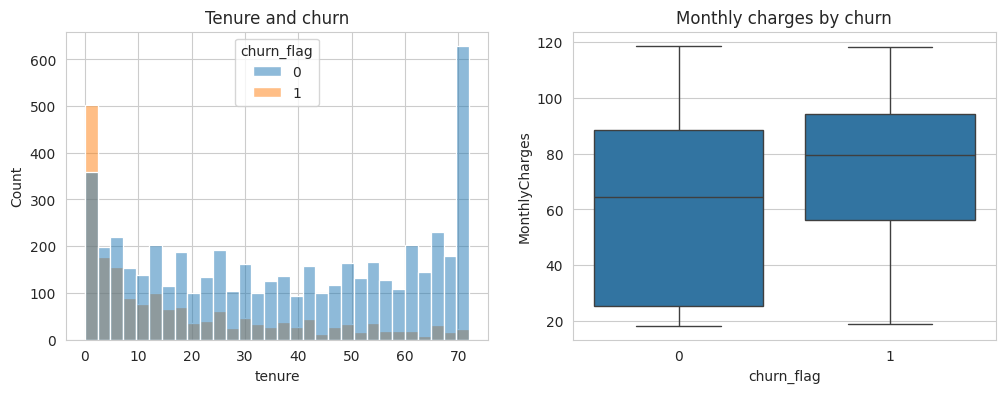

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)
customer_ids = df["customerID"]
data = df.drop(columns=["customerID", "Churn"])

print("Churn rate:", round(data["churn_flag"].mean() * 100, 1), "%")
print("\nChurn % by contract:")
print((df.groupby("Contract")["churn_flag"].mean() * 100).round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=data, x="tenure", hue="churn_flag", bins=30, ax=ax[0])
ax[0].set_title("Tenure and churn")
sns.boxplot(data=data, x="churn_flag", y="MonthlyCharges", ax=ax[1])
ax[1].set_title("Monthly charges by churn")
plt.show()

## Step 4: Baseline and XGBoost

Baseline accuracy (always say No): 0.735
Logistic Regression AUC: 0.842
XGBoost AUC: 0.848

5-fold AUC, Logistic Regression: 0.845 +/- 0.006
5-fold AUC, XGBoost: 0.849 +/- 0.009
The difference is smaller than the fold-to-fold spread, so XGBoost and Logistic Regression are about equally good here.

Average predicted churn on test: 26.6 % vs actual churn 26.5 %
Brier score (lower is better, a calibrated model is close to the actual rate): 0.135
No class weighting is used, because it would push probabilities far above the real churn rate.
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



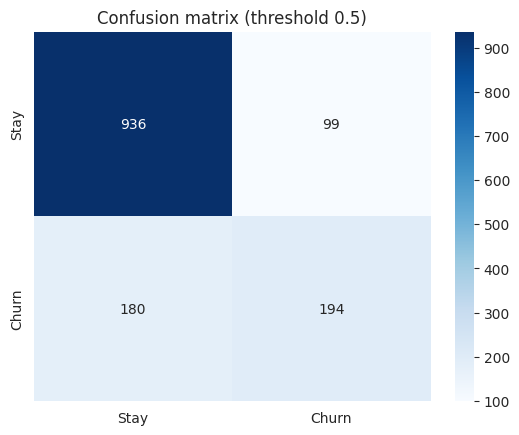

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

X = pd.get_dummies(data.drop(columns=["churn_flag"]), drop_first=False).astype(float)
y = data["churn_flag"]
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state=42, stratify=y)

print("Baseline accuracy (always say No):", round(1 - y_test.mean(), 3))

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import brier_score_loss

lr = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=3000))])
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
print("Logistic Regression AUC:", round(roc_auc_score(y_test, lr_prob), 3))

# shallow, regularised trees work better on this kind of table data than deep ones
xgb_settings = dict(n_estimators=250, max_depth=3, learning_rate=0.04, subsample=0.8, colsample_bytree=0.6,
                    min_child_weight=5, reg_lambda=5, eval_metric="logloss", random_state=42)
xgb = XGBClassifier(**xgb_settings)
xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print("XGBoost AUC:", round(roc_auc_score(y_test, xgb_prob), 3))

cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
lr_cv = cross_val_score(lr, X, y, cv=cv_check, scoring="roc_auc")
xgb_cv = cross_val_score(XGBClassifier(**xgb_settings), X, y, cv=cv_check, scoring="roc_auc")
print("\n5-fold AUC, Logistic Regression:", round(lr_cv.mean(), 3), "+/-", round(lr_cv.std(), 3))
print("5-fold AUC, XGBoost:", round(xgb_cv.mean(), 3), "+/-", round(xgb_cv.std(), 3))
if xgb_cv.mean() - lr_cv.mean() < xgb_cv.std():
    print("The difference is smaller than the fold-to-fold spread, so XGBoost and Logistic Regression are about equally good here.")

print("\nAverage predicted churn on test:", round(xgb_prob.mean() * 100, 1), "% vs actual churn", round(y_test.mean() * 100, 1), "%")
print("Brier score (lower is better, a calibrated model is close to the actual rate):", round(brier_score_loss(y_test, xgb_prob), 3))
print("No class weighting is used, because it would push probabilities far above the real churn rate.")

pred = (xgb_prob > 0.5).astype(int)
print(classification_report(y_test, pred))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"])
plt.title("Confusion matrix (threshold 0.5)")
plt.show()

## Step 5: Best threshold using business cost
Assumptions (edit them): a retention offer costs 200 per customer contacted, works 30% of the time, and a saved customer is worth 1500.

The threshold is chosen using **cross-validated predictions on the training data only**. Then profit is checked on the test data, which was not used to choose it. Choosing the threshold on the same data you report on makes the profit look too good.

Profit table on training data (cross-validated):
 threshold  contacted  churners_caught   profit  profit_per_customer
      0.10       3424             1396 -56600.0                -10.0
      0.15       3004             1345   4450.0                  0.8
      0.20       2686             1292  44200.0                  7.8
      0.25       2396             1226  72500.0                 12.9
      0.30       2123             1149  92450.0                 16.4
      0.35       1825             1050 107500.0                 19.1
      0.40       1574              963 118550.0                 21.0
      0.45       1374              886 123900.0                 22.0
      0.50       1182              792 120000.0                 21.3
      0.55       1002              686 108300.0                 19.2
      0.60        806              580  99800.0                 17.7
      0.65        635              475  86750.0                 15.4
      0.70        485              379  73550.0       

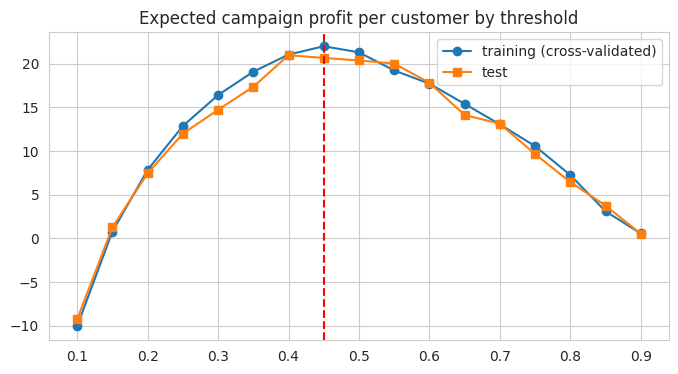

In [5]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

offer_cost = 200
success_rate = 0.30
customer_value = 1500

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_train = cross_val_predict(XGBClassifier(**xgb_settings), X_train, y_train, cv=cv5, method="predict_proba")[:, 1]

def profit_table(prob, truth):
    rows = []
    for t in np.arange(0.1, 0.91, 0.05):
        flagged = prob >= t
        tp = int(((flagged) & (truth == 1)).sum())
        contacted = int(flagged.sum())
        profit = tp * success_rate * customer_value - contacted * offer_cost
        rows.append({"threshold": round(float(t), 2), "contacted": contacted, "churners_caught": tp, "profit": profit,
                     "profit_per_customer": profit / len(truth)})
    return pd.DataFrame(rows)

thr = profit_table(oof_train, y_train.values)
best = thr.loc[thr["profit"].idxmax()]
best_threshold = float(best["threshold"])
print("Profit table on training data (cross-validated):")
print(thr.round({"profit_per_customer": 1}).to_string(index=False))
print("\nBest threshold chosen on training data:", best_threshold)

test_thr = profit_table(xgb_prob, y_test.values)
test_row = test_thr[test_thr["threshold"] == best_threshold].iloc[0]
print("Profit on the TEST data at that threshold:", round(test_row["profit"]), "from", int(test_row["contacted"]), "customers contacted,", int(test_row["churners_caught"]), "churners caught")
print("Profit per customer: training", round(best["profit_per_customer"], 1), "| test", round(test_row["profit_per_customer"], 1))

plt.figure(figsize=(8, 4))
plt.plot(thr["threshold"], thr["profit_per_customer"], marker="o", label="training (cross-validated)")
plt.plot(test_thr["threshold"], test_thr["profit_per_customer"], marker="s", label="test")
plt.axvline(best_threshold, color="red", linestyle="--")
plt.legend()
plt.title("Expected campaign profit per customer by threshold")
plt.show()

## Step 6: SHAP explanations
SHAP shows how much each feature pushes a customer's churn score up or down.

SHAP TreeExplainer worked


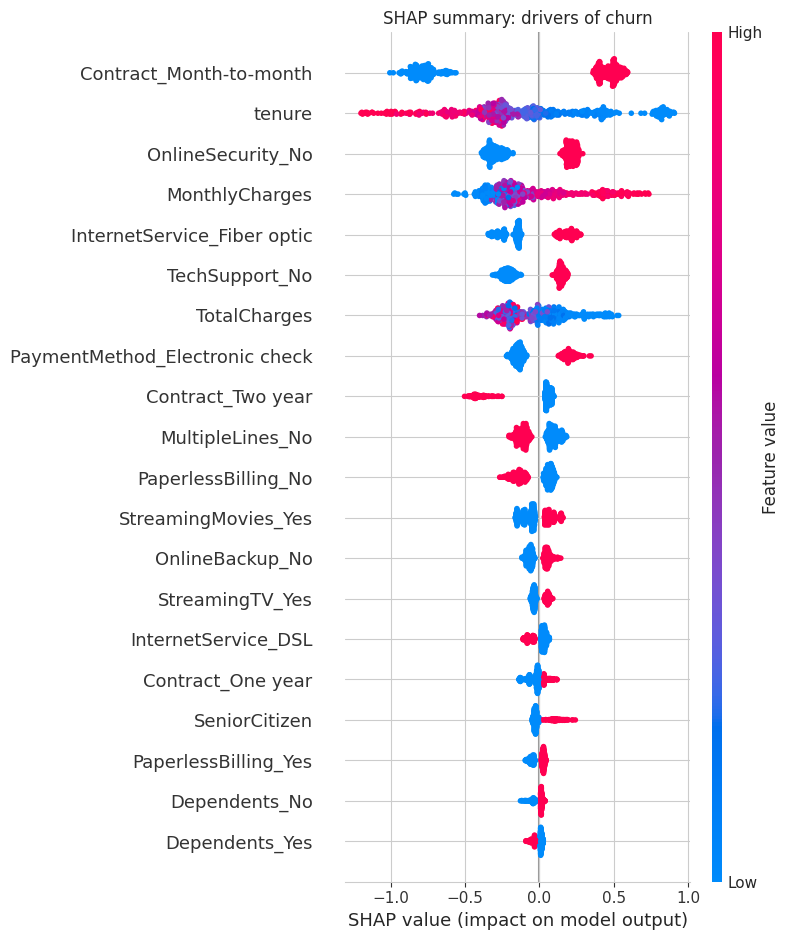

Contract_Month-to-month           0.615
tenure                            0.392
OnlineSecurity_No                 0.258
MonthlyCharges                    0.249
InternetService_Fiber optic       0.194
TechSupport_No                    0.181
TotalCharges                      0.171
PaymentMethod_Electronic check    0.164
Contract_Two year                 0.146
MultipleLines_No                  0.109
dtype: float32


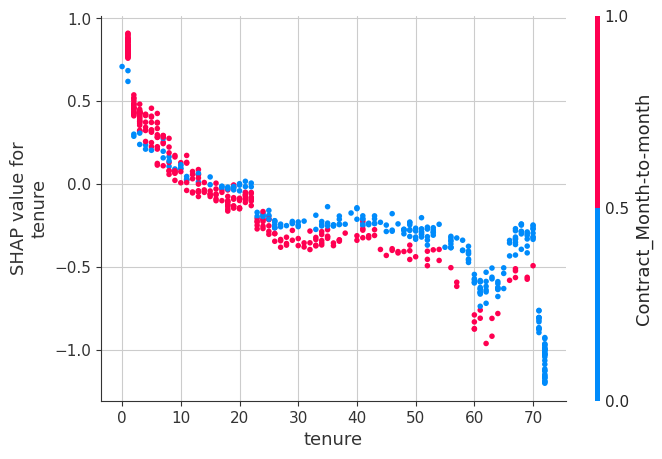

In [6]:
import shap
import xgboost as xgb_lib

X_sample = X_test.sample(min(600, len(X_test)), random_state=1)
try:
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    print("SHAP TreeExplainer worked")
except Exception as e:
    print("TreeExplainer failed, using XGBoost built-in contributions instead:", str(e)[:60])
    contribs = xgb.get_booster().predict(xgb_lib.DMatrix(X_sample), pred_contribs=True)
    shap_values = contribs[:, :-1]

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP summary: drivers of churn")
plt.tight_layout()
plt.show()

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X_sample.columns).sort_values(ascending=False)
print(mean_abs.head(10).round(3))

shap.dependence_plot("tenure", shap_values, X_sample, show=False)
plt.show()

## Step 7: Explain single customers and suggest actions

In [7]:
playbook = {
    "Contract_Month-to-month": "Offer a discounted 1-year plan",
    "tenure": "Send a loyalty or onboarding check-in (new customers leave early)",
    "MonthlyCharges": "Review the plan price and offer a cheaper bundle",
    "InternetService_Fiber optic": "Check fiber service quality and speed complaints",
    "TechSupport_No": "Give a free tech support trial",
    "OnlineSecurity_No": "Give a free online security trial",
    "PaymentMethod_Electronic check": "Give a small bonus for switching to auto-pay",
    "TotalCharges": "Offer a loyalty reward based on lifetime spend",
    "PaperlessBilling_Yes": "Send a proactive billing summary",
    "SeniorCitizen": "Offer assisted support line",
}

def explain_customer(row_number):
    sv = pd.Series(shap_values[row_number], index=X_sample.columns)
    row = X_sample.iloc[row_number]
    prob = xgb.predict_proba(X_sample.iloc[[row_number]])[0, 1]
    push_up = sv[sv > 0].sort_values(ascending=False).head(4)
    print("Churn probability:", round(prob * 100, 1), "%")
    actions = []
    for feat, val in push_up.items():
        print(" - ", feat, "=", row[feat], "raises churn score by", round(val, 2))
        if feat in playbook and playbook[feat] not in actions:
            actions.append(playbook[feat])
    print(" Suggested actions:", actions if len(actions) > 0 else ["General retention call"])

sample_probs = xgb.predict_proba(X_sample)[:, 1]
top_rows = np.argsort(sample_probs)[::-1][:3]
for r in top_rows:
    explain_customer(int(r))
    print()

low_row = int(np.argsort(sample_probs)[0])
print("A low-risk customer for comparison:")
explain_customer(low_row)

Churn probability: 91.6 %
 -  tenure = 1.0 raises churn score by 0.82
 -  Contract_Month-to-month = 1.0 raises churn score by 0.58
 -  TotalCharges = 85.05 raises churn score by 0.41
 -  OnlineSecurity_No = 1.0 raises churn score by 0.27
 Suggested actions: ['Send a loyalty or onboarding check-in (new customers leave early)', 'Offer a discounted 1-year plan', 'Offer a loyalty reward based on lifetime spend', 'Give a free online security trial']

Churn probability: 91.5 %
 -  tenure = 1.0 raises churn score by 0.77
 -  Contract_Month-to-month = 1.0 raises churn score by 0.55
 -  TotalCharges = 95.45 raises churn score by 0.4
 -  OnlineSecurity_No = 1.0 raises churn score by 0.24
 Suggested actions: ['Send a loyalty or onboarding check-in (new customers leave early)', 'Offer a discounted 1-year plan', 'Offer a loyalty reward based on lifetime spend', 'Give a free online security trial']

Churn probability: 88.5 %
 -  Contract_Month-to-month = 1.0 raises churn score by 0.51
 -  MonthlyCha

## Step 8: Retention call list

In [8]:
all_prob = cross_val_predict(XGBClassifier(**xgb_settings), X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11), method="predict_proba")[:, 1]
calls = pd.DataFrame({"customerID": customer_ids.values, "churn_probability": all_prob,
                      "tenure": data["tenure"].values, "Contract": data["Contract"].values,
                      "MonthlyCharges": data["MonthlyCharges"].values, "actual_churn": data["churn_flag"].values})
calls = calls[calls["churn_probability"] >= best_threshold].sort_values("churn_probability", ascending=False)
calls["value_at_risk"] = calls["MonthlyCharges"] * 12

print("Every customer is scored by a model that never saw that customer (5-fold cross-validation), so these numbers are honest.")
print("Customers to contact:", len(calls))
print("Yearly revenue at risk in this list:", round(calls["value_at_risk"].sum()))
print(calls.head(10).round(2))

Every customer is scored by a model that never saw that customer (5-fold cross-validation), so these numbers are honest.
Customers to contact: 1752
Yearly revenue at risk in this list: 1634793
      customerID  churn_probability  tenure        Contract  MonthlyCharges  \
2208  7216-EWTRS               0.94       1  Month-to-month          100.80   
3380  5178-LMXOP               0.93       1  Month-to-month           95.10   
6482  5419-JPRRN               0.92       1  Month-to-month          101.45   
1600  3068-OMWZA               0.92       1  Month-to-month           88.80   
4585  1069-XAIEM               0.92       1  Month-to-month           85.05   
3209  8149-RSOUN               0.91       1  Month-to-month           93.85   
4800  9300-AGZNL               0.91       1  Month-to-month           94.00   
1704  0107-YHINA               0.91       1  Month-to-month           99.75   
1976  9497-QCMMS               0.91       1  Month-to-month           93.55   
2577  4910-GMJOT 

## Step 9: Key insights and export

In [9]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Churn rate:", round(data["churn_flag"].mean() * 100, 1), "%")
print("2. Test AUC: XGBoost", round(roc_auc_score(y_test, xgb_prob), 3), "vs Logistic Regression", round(roc_auc_score(y_test, lr_prob), 3), "| 5-fold:", round(xgb_cv.mean(), 3), "vs", round(lr_cv.mean(), 3))
print("3. Top churn drivers:", mean_abs.head(3).index.tolist())
print("4. Best threshold", best_threshold, "was chosen on training data; profit on the unseen test data:", round(test_row["profit"]))
mtm = data[data["Contract"] == "Month-to-month"]["churn_flag"].mean() * 100
print("5. Month-to-month churn:", round(mtm, 1), "%")

calls.to_csv("churn_call_list.csv", index=False)
thr.to_csv("churn_threshold_profit.csv", index=False)
mean_abs.reset_index().rename(columns={"index": "feature", 0: "mean_abs_shap"}).to_csv("churn_shap_importance.csv", index=False)
print("\nSaved churn_call_list.csv, churn_threshold_profit.csv, churn_shap_importance.csv")

KEY INSIGHTS (calculated from this run)
1. Churn rate: 26.5 %
2. Test AUC: XGBoost 0.848 vs Logistic Regression 0.842 | 5-fold: 0.849 vs 0.845
3. Top churn drivers: ['Contract_Month-to-month', 'tenure', 'OnlineSecurity_No']
4. Best threshold 0.45 was chosen on training data; profit on the unseen test data: 29100
5. Month-to-month churn: 42.7 %

Saved churn_call_list.csv, churn_threshold_profit.csv, churn_shap_importance.csv



Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)